###Environment setup

In [1]:
!pip install kaggle -q

In [2]:
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

! kaggle datasets download -d averkiyoliabev/home-equity-line-of-creditheloc

Dataset URL: https://www.kaggle.com/datasets/averkiyoliabev/home-equity-line-of-creditheloc
License(s): unknown
  0% 0.00/204k [00:00<?, ?B/s]
100% 204k/204k [00:00<00:00, 421MB/s]


In [3]:
! mkdir data/
! unzip ./home-equity-line-of-creditheloc.zip -d data/
! mv "./data/heloc_dataset_v1 (1).csv" "./data/heloc_dataset_v1.csv"

Archive:  ./home-equity-line-of-creditheloc.zip
  inflating: data/heloc_dataset_v1 (1).csv  


In [4]:
! pip install optbinning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.8/214.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 17.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 5.26.1 which is incompatible.


In [5]:
from optbinning import BinningProcess

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import auc, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

###Pre processing

In [7]:
df = pd.read_csv("data/heloc_dataset_v1.csv", sep=",")

In [8]:
variable_names = list(df.columns[1:])

In [9]:
X = df[variable_names].values

In [10]:
# Transform the categorical dichotomic target variable into numerical.

y = df.RiskPerformance.values
mask = y == "Bad"
y[mask] = 1
y[~mask] = 0
y = y.astype(int)

In [11]:
# This dataset has a few special values to avoid
special_codes = [-9, -8, -7]

In [12]:
binning_fit_params = {
    "ExternalRiskEstimate": {"monotonic_trend": "descending"},
    "MSinceOldestTradeOpen": {"monotonic_trend": "descending"},
    "MSinceMostRecentTradeOpen": {"monotonic_trend": "descending"},
    "AverageMInFile": {"monotonic_trend": "descending"},
    "NumSatisfactoryTrades": {"monotonic_trend": "descending"},
    "NumTrades60Ever2DerogPubRec": {"monotonic_trend": "ascending"},
    "NumTrades90Ever2DerogPubRec": {"monotonic_trend": "ascending"},
    "PercentTradesNeverDelq": {"monotonic_trend": "descending"},
    "MSinceMostRecentDelq": {"monotonic_trend": "descending"},
    "NumTradesOpeninLast12M": {"monotonic_trend": "ascending"},
    "MSinceMostRecentInqexcl7days": {"monotonic_trend": "descending"},
    "NumInqLast6M": {"monotonic_trend": "ascending"},
    "NumInqLast6Mexcl7days": {"monotonic_trend": "ascending"},
    "NetFractionRevolvingBurden": {"monotonic_trend": "ascending"},
    "NetFractionInstallBurden": {"monotonic_trend": "ascending"},
    "NumBank2NatlTradesWHighUtilization": {"monotonic_trend": "ascending"}
}

In [13]:
binning_process = BinningProcess(variable_names, special_codes=special_codes,
                                 binning_fit_params=binning_fit_params)

In [14]:
clf1 = Pipeline(steps=[('binning_process', binning_process),
                      ('classifier', LogisticRegression(solver="lbfgs"))])

clf2 = LogisticRegression(solver="lbfgs",max_iter=5000)

clf3 = GradientBoostingClassifier()

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
clf1.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/optbinning/binning/transformations.py:38: RuntimeWarning: invalid value encountered in log
  return np.log((1. / event_rate - 1) * n_event / n_nonevent)


Pipeline(steps=[('binning_process',
                 BinningProcess(binning_fit_params={'AverageMInFile': {'monotonic_trend': 'descending'},
                                                    'ExternalRiskEstimate': {'monotonic_trend': 'descending'},
                                                    'MSinceMostRecentDelq': {'monotonic_trend': 'descending'},
                                                    'MSinceMostRecentInqexcl7days': {'monotonic_trend': 'descending'},
                                                    'MSinceMostRecentTradeOpen': {'monotonic_trend': 'descen...
                                                'MaxDelqEver', 'NumTotalTrades',
                                                'NumTradesOpeninLast12M',
                                                'PercentInstallTrades',
                                                'MSinceMostRecentInqexcl7days',
                                                'NumInqLast6M',
                                                'NumInqLast6Mexcl7days',
                                                'NetFractionRevolvingBurden',
                                                'NetFractionInstallBurden',
                                                'NumRevolvingTradesWBalance',
                                                'NumInstallTradesWBalance',
                                                'NumBank2NatlTradesWHighUtilization',
                                                'PercentTradesWBalance'])),
                ('classifier', LogisticRegression())])

In [17]:
clf2.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [18]:
clf3.fit(X_train, y_train)

GradientBoostingClassifier()

In [19]:
y_pred = clf1.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.66      0.68      1004
           1       0.70      0.74      0.72      1088

    accuracy                           0.70      2092
   macro avg       0.70      0.70      0.70      2092
weighted avg       0.70      0.70      0.70      2092



/usr/local/lib/python3.12/dist-packages/optbinning/binning/transformations.py:38: RuntimeWarning: invalid value encountered in log
  return np.log((1. / event_rate - 1) * n_event / n_nonevent)


In [20]:
y_pred = clf2.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.66      0.68      1004
           1       0.70      0.73      0.72      1088

    accuracy                           0.70      2092
   macro avg       0.70      0.70      0.70      2092
weighted avg       0.70      0.70      0.70      2092



In [21]:
y_pred = clf3.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.66      0.68      1004
           1       0.70      0.75      0.73      1088

    accuracy                           0.71      2092
   macro avg       0.71      0.70      0.70      2092
weighted avg       0.71      0.71      0.70      2092



In [22]:

probs = clf1.predict_proba(X_test)
preds = probs[:,1]
fpr1, tpr1, threshold = roc_curve(y_test, preds)
roc_auc1 = auc(fpr1, tpr1)

probs = clf2.predict_proba(X_test)
preds = probs[:,1]
fpr2, tpr2, threshold = roc_curve(y_test, preds)
roc_auc2 = auc(fpr2, tpr2)

probs = clf3.predict_proba(X_test)
preds = probs[:,1]
fpr3, tpr3, threshold = roc_curve(y_test, preds)
roc_auc3 = auc(fpr3, tpr3)

/usr/local/lib/python3.12/dist-packages/optbinning/binning/transformations.py:38: RuntimeWarning: invalid value encountered in log
  return np.log((1. / event_rate - 1) * n_event / n_nonevent)


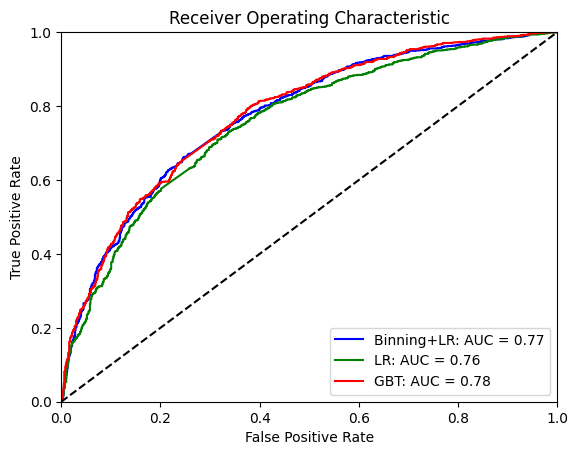

In [23]:
plt.title('Receiver Operating Characteristic')
plt.plot(fpr1, tpr1, 'b', label='Binning+LR: AUC = {0:.2f}'.format(roc_auc1))
plt.plot(fpr2, tpr2, 'g', label='LR: AUC = {0:.2f}'.format(roc_auc2))
plt.plot(fpr3, tpr3, 'r', label='GBT: AUC = {0:.2f}'.format(roc_auc3))
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1],'k--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

### Rulefit Model

In [26]:
!pip install imodels -q
from imodels import RuleFitClassifier
from sklearn.metrics import roc_auc_score

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Removing missing values

In [29]:
X_train_clean = X_train.astype(float).copy()
X_test_clean  = X_test.astype(float).copy()
y_train_clean = y_train.copy()
y_test_clean  = y_test.copy()

for code in special_codes:
    X_train_clean[X_train_clean == code] = np.nan

mask_train = ~np.isnan(X_train_clean).any(axis=1)

X_train_clean = X_train_clean[mask_train]
y_train_clean = y_train_clean[mask_train]

for code in special_codes:
    X_test_clean[X_test_clean == code] = np.nan

mask_test = ~np.isnan(X_test_clean).any(axis=1)

X_test_clean = X_test_clean[mask_test]
y_test_clean = y_test_clean[mask_test]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [32]:
print(X_train_clean.shape, y_train_clean.sum(), (y_train_clean == 0).sum())


(1998, 23) 1258 740


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Model Training

In [82]:
rulefit = RuleFitClassifier(
    n_estimators=150,
    tree_size=2,
    max_rules=70,
    include_linear=True,
    random_state=42)

rulefit.fit(
    X_train_clean,
    y_train_clean,
    feature_names=variable_names)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

RuleFitClassifier(max_rules=70, n_estimators=150, random_state=42, tree_size=2)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Evaluation

In [96]:
y_train_proba = rulefit.predict_proba(X_train_clean)[:, 1]
y_test_proba  = rulefit.predict_proba(X_test_clean)[:, 1]

print("AUC train :", roc_auc_score(y_train_clean, y_train_proba))
print("AUC test  :", roc_auc_score(y_test_clean,  y_test_proba))

y_test_pred = (y_test_proba >= 0.35).astype(int)
print(classification_report(y_test_clean, y_test_pred))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

AUC train : 0.7738291152838053
AUC test  : 0.7374762310668154
              precision    recall  f1-score   support

           0       0.68      0.60      0.64       202
           1       0.75      0.81      0.78       302

    accuracy                           0.73       504
   macro avg       0.72      0.71      0.71       504
weighted avg       0.72      0.73      0.72       504



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Rules Extraction

In [97]:
rules = rulefit._get_rules(exclude_zero_coef=False)

rules_rules = rules[
    (rules['type'] == 'rule') &
    (rules['coef'] != 0)].copy()

rules_rules = rules_rules.sort_values('importance', ascending=False)

rules_rules.head(15)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,rule,type,coef,support,importance
76,ExternalRiskEstimate <= 59.5,rule,0.477904,0.211712,0.195234
36,MSinceMostRecentInqexcl7days > 0.5,rule,-0.356340,0.366366,0.171688
31,PercentTradesNeverDelq > 95.5,rule,-0.327373,0.207708,0.132804
29,MSinceMostRecentInqexcl7days > 1.5,rule,-0.200827,0.289289,0.091061
65,AverageMInFile <= 75.5,rule,0.179468,0.539039,0.089460
25,ExternalRiskEstimate > 75.5,rule,-0.259750,0.129630,0.087249
57,MSinceMostRecentDelq <= 27.5,rule,0.164400,0.707708,0.074772
78,MSinceOldestTradeOpen <= 71.5,rule,0.362752,0.043043,0.073622
23,ExternalRiskEstimate > 74.5,rule,-0.201643,0.152653,0.072521
37,MSinceMostRecentDelq > 25.5,rule,-0.130629,0.315816,0.060721


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
